# Chapter 05: Similarity in the Euclidean Plane

**Source orientation.** Printed pages 67-76; PDF pages 85-94. The scanned pages were used only to identify the chapter's concepts and sequence; the prose, code, diagrams, data, and checks below are original.

**Chapter goal.** Learn how Euclidean similarity sits between congruence and affine freedom: it preserves angles and scales all lengths by one positive factor, but it may keep or reverse orientation. By the end, you should be able to compute the center and ratio of a dilation, construct the two centers of similitude of two circles, recognize the nine-point center as a center of similitude, find the unique fixed point of a non-isometric similarity, and distinguish direct from opposite similarities.

**Computational translation guide.**

| Synthetic idea | Computational model used here | Invariant to inspect |
| --- | --- | --- |
| Dilation centered at `O` with signed ratio `lambda` | vector map `P' = O + lambda(P-O)` | every line maps to a parallel line; lengths scale by `abs(lambda)` |
| Centers of similitude of two circles | solve for the homothety center mapping one center/radius to the other | corresponding radius points and the center are collinear |
| Nine-point center | compute `O, G, H, N` from triangle coordinates | `N = (O+H)/2`; nine-point radius is half the circumradius |
| Similarity fixed point | complex affine maps `z' = a z + b` or `z' = a conjugate(z) + b` | fixed point solves a 2-by-2 linear system unless the map is a translation/isometry edge case |
| Direct versus opposite similarity | determinant sign of the real 2-by-2 linear part | direct preserves oriented area; opposite reverses it |

**Compact visual storyboard implemented in this notebook.** Dilation and parallel-line invariants, two homothety centers for circles, nine-point center under two half-scale maps, spiral-similarity fixed point, direct/opposite classifier, nested synthetic image lab, and final artifact/invariant checks.


In [1]:
from __future__ import annotations

import json
import math
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.graph_objects as go
import sympy as sp
from IPython.display import Markdown, display
from PIL import Image as PILImage, ImageDraw

CHAPTER_NO = 5
HERE = Path.cwd().resolve()
BOOK_ROOT = None
for candidate in [HERE, *HERE.parents]:
    if (candidate / "00-book-index.ipynb").exists() and (candidate / "utils").exists():
        BOOK_ROOT = candidate
        break
if BOOK_ROOT is None:
    for candidate in [HERE, *HERE.parents]:
        if candidate.name == "Introduction-to-Geometry":
            BOOK_ROOT = candidate
            break
if BOOK_ROOT is None:
    raise RuntimeError("Could not locate Introduction-to-Geometry book root")
if str(BOOK_ROOT) not in sys.path:
    sys.path.insert(0, str(BOOK_ROOT))

from utils import assert_artifacts, display_artifact, ensure_chapter_artifact_dirs, write_csv, write_json

ARTIFACT_DIRS = ensure_chapter_artifact_dirs(CHAPTER_NO, BOOK_ROOT)
FIG_DIR = ARTIFACT_DIRS["figures"]
HTML_DIR = ARTIFACT_DIRS["html"]
CHECK_DIR = ARTIFACT_DIRS["checks"]
TABLE_DIR = ARTIFACT_DIRS["tables"]
DATA_DIR = ARTIFACT_DIRS["data"]

plt.rcParams.update({
    "figure.dpi": 140,
    "savefig.dpi": 180,
    "font.size": 10,
    "axes.titlesize": 12,
    "axes.labelsize": 9,
})

artifact_paths: dict[str, Path] = {}
checks: dict[str, object] = {
    "chapter": CHAPTER_NO,
    "source_span": {"printed_pages": "67-76", "pdf_pages": "85-94"},
    "numeric_invariants": {},
    "symbolic_invariants": {},
    "artifacts": {},
}


def rel(path: Path) -> str:
    return path.resolve().relative_to(BOOK_ROOT.resolve()).as_posix()


def savefig(name: str, fig, **kwargs) -> Path:
    path = FIG_DIR / name
    fig.savefig(path, bbox_inches="tight", **kwargs)
    plt.close(fig)
    artifact_paths[name] = path
    checks["artifacts"][name] = rel(path)
    return path


def cross2(a, b) -> float:
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    return float(a[0] * b[1] - a[1] * b[0])


def oriented_area(points: np.ndarray) -> float:
    pts = np.asarray(points, dtype=float)
    return 0.5 * sum(cross2(pts[(i + 1) % len(pts)], pts[i]) * -1 for i in range(len(pts)))


def circumcenter(A: np.ndarray, B: np.ndarray, C: np.ndarray) -> np.ndarray:
    ax, ay = A
    bx, by = B
    cx, cy = C
    d = 2 * (ax * (by - cy) + bx * (cy - ay) + cx * (ay - by))
    if abs(d) < 1e-12:
        raise ValueError("Degenerate triangle")
    ux = ((ax * ax + ay * ay) * (by - cy) + (bx * bx + by * by) * (cy - ay) + (cx * cx + cy * cy) * (ay - by)) / d
    uy = ((ax * ax + ay * ay) * (cx - bx) + (bx * bx + by * by) * (ax - cx) + (cx * cx + cy * cy) * (bx - ax)) / d
    return np.array([ux, uy], dtype=float)


def complex_to_xy(z: complex) -> np.ndarray:
    return np.array([z.real, z.imag], dtype=float)


## Reading Similarity As Invariant Plus Scale

A similarity is deliberately weaker than an isometry: it may change every length, but it must change all lengths by the same ratio and preserve the angle structure that makes shapes recognizable. This chapter uses that distinction as the reading rule for every artifact. The dilation panel asks which lines remain parallel and which points move along rays from the center. The homothety figure uses two circles because their centers of similitude give concrete locations where a scale comparison becomes a point. The nine-point-center check ties the classical triangle geometry back to a half-scale map rather than treating it as a decorative circle fact.

The spiral similarity and direct/opposite classifier add the missing orientation data. A direct similarity rotates and scales with positive determinant; an opposite similarity includes a reflection and reverses orientation. The image lab turns the same idea into a synthetic raster experiment: copies can grow, rotate, and reflect, but the numeric table records whether scale ratios, determinant signs, and fixed-point equations agree with the visual story. Read the notebook by asking what survives after scale is allowed to change.


## 1. Dilation: a center, a signed ratio, and parallel images

A dilation is the simplest non-isometric similarity in this chapter. Once a center `O` and a signed ratio `lambda` are chosen, every point moves on its own ray through `O`:

```text
P' = O + lambda(P - O)
```

The sign tells whether `P` and `P'` are on the same side of `O` or opposite sides. The absolute value is the length scale. The important inspection target in the figure is not just the enlarged triangle: compare each original edge with its image edge. The directions agree up to sign, so every line has been sent to a parallel line.


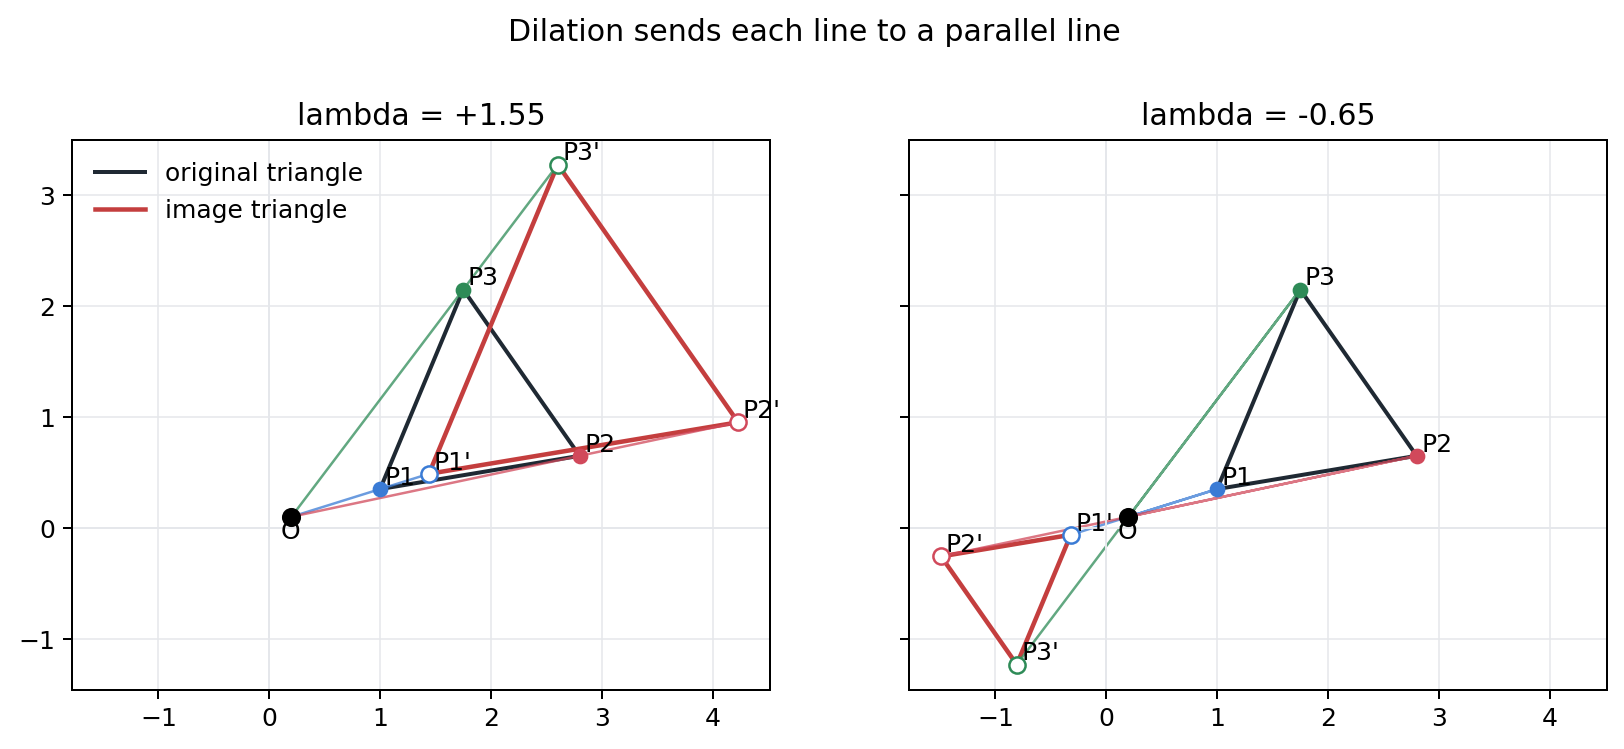

{'max_parallel_cross_residual': 8.881784197001252e-16,
 'max_length_scale_residual': np.float64(4.440892098500626e-16),
 'ratios_checked': [1.55, -0.65]}

In [2]:
O = np.array([0.2, 0.1])
lambdas = [1.55, -0.65]
triangle = np.array([[1.0, 0.35], [2.8, 0.65], [1.75, 2.15]])
colors = ["#3a7bd5", "#d1495b", "#2e8b57"]
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), sharex=True, sharey=True)
line_parallel_residuals = []
length_scale_residuals = []

for ax, lam in zip(axes, lambdas):
    image = O + lam * (triangle - O)
    closed = np.vstack([triangle, triangle[0]])
    closed_img = np.vstack([image, image[0]])
    ax.plot(closed[:, 0], closed[:, 1], color="#1f2933", lw=1.6, label="original triangle")
    ax.plot(closed_img[:, 0], closed_img[:, 1], color="#c43e3e", lw=1.8, label="image triangle")
    for i, (P, Pp) in enumerate(zip(triangle, image)):
        ax.plot([O[0], P[0], Pp[0]], [O[1], P[1], Pp[1]], color=colors[i], lw=1, alpha=0.75)
        ax.scatter(*P, s=28, color=colors[i], zorder=4)
        ax.scatter(*Pp, s=42, facecolor="white", edgecolor=colors[i], zorder=4)
        ax.text(P[0] + 0.04, P[1] + 0.04, f"P{i+1}")
        ax.text(Pp[0] + 0.04, Pp[1] + 0.04, f"P{i+1}'")
    ax.scatter(*O, s=44, color="black", zorder=5)
    ax.text(O[0] - 0.1, O[1] - 0.2, "O")
    ax.set_title(f"lambda = {lam:+.2f}")
    ax.set_aspect("equal")
    ax.grid(True, color="#e5e7eb", lw=0.6)
    ax.axhline(0, color="#e5e7eb", lw=0.8)
    ax.axvline(0, color="#e5e7eb", lw=0.8)

    for i in range(3):
        edge = triangle[(i + 1) % 3] - triangle[i]
        edge_img = image[(i + 1) % 3] - image[i]
        line_parallel_residuals.append(abs(cross2(edge, edge_img)))
        length_scale_residuals.append(abs(np.linalg.norm(edge_img) / np.linalg.norm(edge) - abs(lam)))

axes[0].legend(loc="upper left", frameon=False)
fig.suptitle("Dilation sends each line to a parallel line", y=1.02)
path = savefig("dilation_parallel_lines.png", fig)

checks["numeric_invariants"]["dilation"] = {
    "max_parallel_cross_residual": max(line_parallel_residuals),
    "max_length_scale_residual": max(length_scale_residuals),
    "ratios_checked": lambdas,
}
assert max(line_parallel_residuals) < 1e-12
assert max(length_scale_residuals) < 1e-12

display_artifact(path, width=820)
checks["numeric_invariants"]["dilation"]


## 2. Two centers of similitude for two unequal circles

Two nonconcentric unequal circles are related by two homotheties. One has positive ratio and puts corresponding radius points on the same side of the two centers; the other has negative ratio and pairs opposite radius points. The centers are visible as the two points from which the circles look like scaled copies of one another.

For centers `C1, C2` and radii `r1, r2`, the external and internal centers are

```text
S_ext = (r1 C2 - r2 C1)/(r1-r2),    S_int = (r1 C2 + r2 C1)/(r1+r2).
```

Inspect the colored chords: `S_ext, P, P'` are collinear for same-direction radius points, while `S_int, P, Q'` are collinear for opposite radius points.


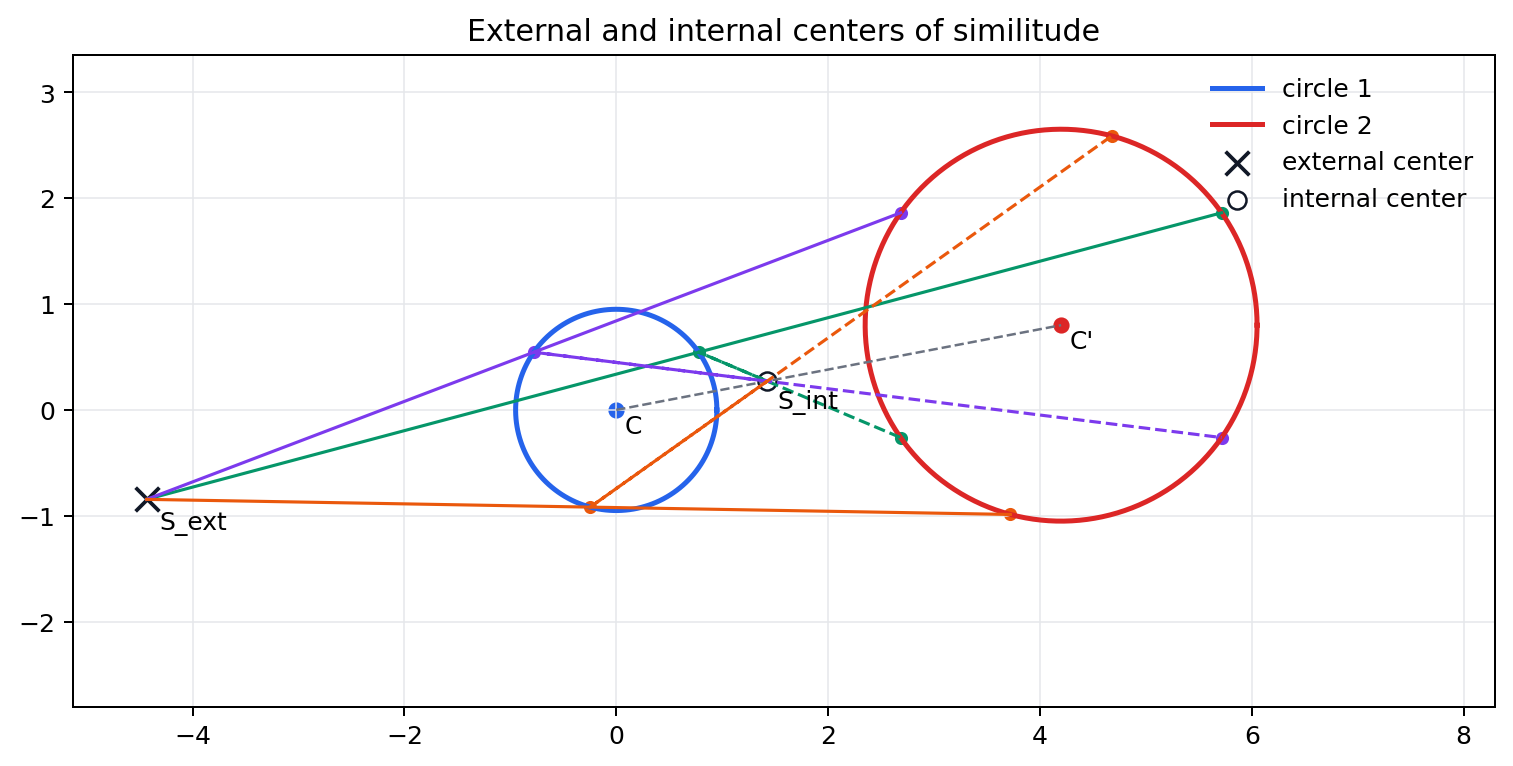

{'external_center': [-4.43333333, -0.84444444],
 'internal_center': [1.425, 0.27142857],
 'max_external_collinearity_residual': 1.7763568394002505e-15,
 'max_internal_collinearity_residual': 4.440892098500626e-16,
 'external_scale': 1.9473684210526319,
 'internal_scale': -1.9473684210526319}

In [3]:
C1 = np.array([0.0, 0.0])
C2 = np.array([4.2, 0.8])
r1, r2 = 0.95, 1.85
S_ext = (r1 * C2 - r2 * C1) / (r1 - r2)
S_int = (r1 * C2 + r2 * C1) / (r1 + r2)
angles = np.deg2rad([35, 145, 255])
residuals_ext = []
residuals_int = []

fig, ax = plt.subplots(figsize=(10.2, 5.4))
t = np.linspace(0, 2 * np.pi, 320)
for center, radius, color, label in [(C1, r1, "#2563eb", "circle 1"), (C2, r2, "#dc2626", "circle 2")]:
    ax.plot(center[0] + radius * np.cos(t), center[1] + radius * np.sin(t), color=color, lw=2, label=label)
    ax.scatter(*center, s=30, color=color)
    ax.text(center[0] + 0.08, center[1] - 0.22, "C" if label == "circle 1" else "C'")

ax.scatter(*S_ext, marker="x", s=90, color="#111827", label="external center")
ax.scatter(*S_int, marker="o", s=52, color="#111827", facecolors="white", label="internal center")
ax.text(S_ext[0] + 0.12, S_ext[1] - 0.28, "S_ext")
ax.text(S_int[0] + 0.1, S_int[1] - 0.25, "S_int")
ax.plot([C1[0], C2[0]], [C1[1], C2[1]], color="#6b7280", lw=1, ls="--")

for theta, color in zip(angles, ["#059669", "#7c3aed", "#ea580c"]):
    u = np.array([np.cos(theta), np.sin(theta)])
    P = C1 + r1 * u
    P_same = C2 + r2 * u
    P_opp = C2 - r2 * u
    ax.plot([S_ext[0], P[0], P_same[0]], [S_ext[1], P[1], P_same[1]], color=color, lw=1.25)
    ax.plot([S_int[0], P[0], P_opp[0]], [S_int[1], P[1], P_opp[1]], color=color, lw=1.25, ls="--")
    ax.scatter([P[0], P_same[0], P_opp[0]], [P[1], P_same[1], P_opp[1]], s=18, color=color)
    residuals_ext.append(abs(cross2(P - S_ext, P_same - S_ext)))
    residuals_int.append(abs(cross2(P - S_int, P_opp - S_int)))

ax.set_aspect("equal")
ax.set_xlim(S_ext[0] - 0.7, 8.3)
ax.set_ylim(-2.8, 3.35)
ax.set_title("External and internal centers of similitude")
ax.grid(True, color="#e5e7eb", lw=0.6)
ax.legend(loc="upper right", frameon=False)
path = savefig("homothety_centers_two_circles.png", fig)

checks["numeric_invariants"]["centers_of_similitude"] = {
    "external_center": S_ext.round(8).tolist(),
    "internal_center": S_int.round(8).tolist(),
    "max_external_collinearity_residual": max(residuals_ext),
    "max_internal_collinearity_residual": max(residuals_int),
    "external_scale": r2 / r1,
    "internal_scale": -r2 / r1,
}
assert max(residuals_ext) < 1e-10
assert max(residuals_int) < 1e-10

display_artifact(path, width=820)
checks["numeric_invariants"]["centers_of_similitude"]


## 3. The nine-point center as a center of similitude

The chapter uses dilations to locate the nine-point circle. In coordinates, this can be checked without guessing the picture:

- the circumcenter is `O`, the orthocenter is `H`, and the nine-point center is `N = (O+H)/2`;
- the dilation centered at the centroid `G` with ratio `-1/2` sends each vertex to the midpoint of the opposite side;
- the dilation centered at `H` with ratio `1/2` sends each vertex to the midpoint between that vertex and the orthocenter;
- all six image points lie on the circle centered at `N` with radius half the circumradius.

The figure marks both half-scale triangles. The invariant to inspect is that the two different dilations land on the same circle.


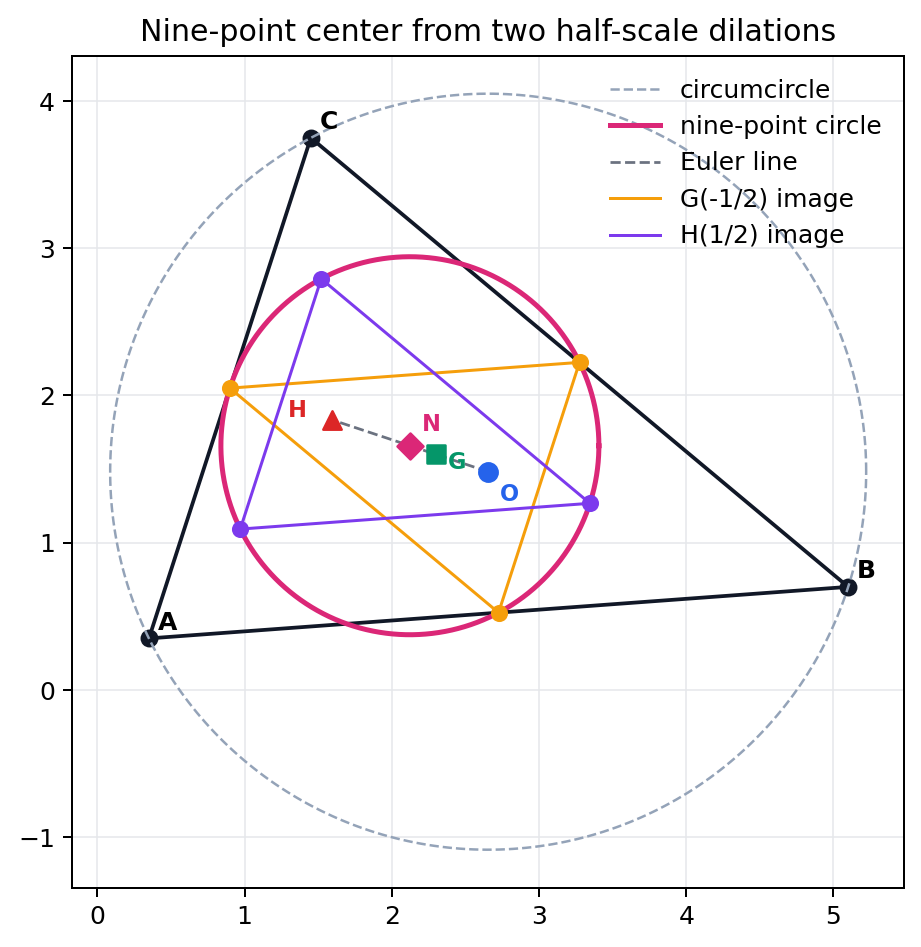

{'midpoint_OH_residual': 0.0,
 'G_minus_half_to_side_midpoints_residual': 6.280369834735101e-16,
 'max_nine_point_radius_residual': 2.220446049250313e-16,
 'circumradius': 2.567646094895157,
 'nine_point_radius': 1.2838230474475785}

In [4]:
A = np.array([0.35, 0.35])
B = np.array([5.1, 0.7])
C = np.array([1.45, 3.75])
tri = np.array([A, B, C])
O_circ = circumcenter(A, B, C)
G = tri.mean(axis=0)
H = A + B + C - 2 * O_circ
N = 0.5 * (O_circ + H)
R = np.linalg.norm(A - O_circ)

medial_from_G = G - 0.5 * (tri - G)
midpoints = np.array([(B + C) / 2, (C + A) / 2, (A + B) / 2])
orthic_midpoints = H + 0.5 * (tri - H)
nine_points = np.vstack([midpoints, orthic_midpoints])
radii = np.linalg.norm(nine_points - N, axis=1)

fig, ax = plt.subplots(figsize=(8.0, 6.0))
closed = np.vstack([tri, tri[0]])
ax.plot(closed[:, 0], closed[:, 1], color="#111827", lw=1.5)
for label, P in zip(["A", "B", "C"], tri):
    ax.scatter(*P, s=38, color="#111827")
    ax.text(P[0] + 0.06, P[1] + 0.06, label, weight="bold")

u = np.linspace(0, 2 * np.pi, 360)
ax.plot(O_circ[0] + R * np.cos(u), O_circ[1] + R * np.sin(u), color="#94a3b8", lw=1.0, ls="--", label="circumcircle")
ax.plot(N[0] + (R / 2) * np.cos(u), N[1] + (R / 2) * np.sin(u), color="#db2777", lw=2.0, label="nine-point circle")
ax.plot([O_circ[0], G[0], N[0], H[0]], [O_circ[1], G[1], N[1], H[1]], color="#6b7280", lw=1.1, ls="--", label="Euler line")

center_label_offsets = {"O": (0.08, -0.20), "G": (0.08, -0.10), "N": (0.08, 0.10), "H": (-0.30, 0.02)}
for label, P, marker, color in [
    ("O", O_circ, "o", "#2563eb"),
    ("G", G, "s", "#059669"),
    ("N", N, "D", "#db2777"),
    ("H", H, "^", "#dc2626"),
]:
    ax.scatter(*P, s=54, marker=marker, color=color, zorder=4)
    dx, dy = center_label_offsets[label]
    ax.text(P[0] + dx, P[1] + dy, label, color=color, weight="bold", fontsize=9)

for P in midpoints:
    ax.scatter(*P, s=34, color="#f59e0b", zorder=5)
for P in orthic_midpoints:
    ax.scatter(*P, s=34, color="#7c3aed", zorder=5)

ax.plot(np.vstack([midpoints, midpoints[0]])[:, 0], np.vstack([midpoints, midpoints[0]])[:, 1], color="#f59e0b", lw=1.2, label="G(-1/2) image")
ax.plot(np.vstack([orthic_midpoints, orthic_midpoints[0]])[:, 0], np.vstack([orthic_midpoints, orthic_midpoints[0]])[:, 1], color="#7c3aed", lw=1.2, label="H(1/2) image")
ax.set_aspect("equal")
ax.set_title("Nine-point center from two half-scale dilations")
ax.grid(True, color="#e5e7eb", lw=0.6)
ax.legend(loc="upper right", frameon=False)
path = savefig("nine_point_center_under_scaling.png", fig)

checks["numeric_invariants"]["nine_point_center"] = {
    "midpoint_OH_residual": float(np.linalg.norm(N - (O_circ + H) / 2)),
    "G_minus_half_to_side_midpoints_residual": float(np.max(np.linalg.norm(medial_from_G - midpoints, axis=1))),
    "max_nine_point_radius_residual": float(np.max(np.abs(radii - R / 2))),
    "circumradius": float(R),
    "nine_point_radius": float(R / 2),
}
assert checks["numeric_invariants"]["nine_point_center"]["midpoint_OH_residual"] < 1e-12
assert checks["numeric_invariants"]["nine_point_center"]["G_minus_half_to_side_midpoints_residual"] < 1e-12
assert checks["numeric_invariants"]["nine_point_center"]["max_nine_point_radius_residual"] < 1e-10

display_artifact(path, width=760)
checks["numeric_invariants"]["nine_point_center"]


## 4. The invariant point of a spiral similarity

A direct similarity in complex coordinates has the form

```text
z' = a z + b,      a = mu(cos theta + i sin theta).
```

If `a != 1`, the fixed point is `z0 = b/(1-a)`. Around that point the map is simply a dilation by `mu` followed by a rotation by `theta`. The Plotly artifact below makes this inspectable: every orbit turns by the same angle and has distances from `z0` multiplied by the same factor at each step.


In [5]:
mu = 0.78
theta = math.radians(38)
a = mu * complex(math.cos(theta), math.sin(theta))
b = complex(1.15, -0.35)
z0 = b / (1 - a)
seeds = [complex(-3.0, -1.2), complex(-2.0, 2.2), complex(2.1, 1.1), complex(2.8, -1.5)]
steps = 10
fig = go.Figure()
ratio_residuals = []
angle_residuals = []

for idx, seed in enumerate(seeds):
    orbit = [seed]
    for _ in range(steps):
        orbit.append(a * orbit[-1] + b)
    xs = [z.real for z in orbit]
    ys = [z.imag for z in orbit]
    fig.add_trace(go.Scatter(x=xs, y=ys, mode="lines+markers", name=f"orbit {idx+1}"))
    for z, zp in zip(orbit[:-1], orbit[1:]):
        ratio_residuals.append(abs(abs(zp - z0) / abs(z - z0) - mu))
        angle = np.angle((zp - z0) / (z - z0))
        angle_residuals.append(abs(np.angle(np.exp(1j * (angle - theta)))))

circle_t = np.linspace(0, 2 * np.pi, 180)
for radius in [0.6, 1.2, 2.4]:
    fig.add_trace(go.Scatter(
        x=(z0.real + radius * np.cos(circle_t)).tolist(),
        y=(z0.imag + radius * np.sin(circle_t)).tolist(),
        mode="lines",
        line=dict(color="rgba(80,80,80,0.25)", dash="dot"),
        showlegend=False,
        hoverinfo="skip",
    ))
fig.add_trace(go.Scatter(x=[z0.real], y=[z0.imag], mode="markers+text", text=["fixed point"], textposition="top center", marker=dict(size=12, color="black"), name="z0"))
fig.update_layout(
    title="Spiral similarity: all orbits rotate and scale around one fixed point",
    xaxis=dict(scaleanchor="y", scaleratio=1, zeroline=False, gridcolor="#eeeeee"),
    yaxis=dict(zeroline=False, gridcolor="#eeeeee"),
    width=860,
    height=620,
    template="plotly_white",
)
html_path = HTML_DIR / "spiral_similarity_fixed_point.html"
if html_path.exists():
    html_path.unlink()
fig.write_html(html_path, include_plotlyjs="cdn", full_html=True)
artifact_paths[html_path.name] = html_path
checks["artifacts"][html_path.name] = rel(html_path)

z, aa, bb = sp.symbols("z aa bb")
symbolic_fixed_residual = sp.simplify(aa * (bb / (1 - aa)) + bb - (bb / (1 - aa)))
checks["symbolic_invariants"]["direct_similarity_fixed_point_residual"] = str(symbolic_fixed_residual)
checks["numeric_invariants"]["spiral_similarity"] = {
    "mu": mu,
    "theta_degrees": math.degrees(theta),
    "fixed_point": [z0.real, z0.imag],
    "fixed_point_residual": abs(a * z0 + b - z0),
    "max_orbit_scale_residual": max(ratio_residuals),
    "max_orbit_angle_residual_radians": max(angle_residuals),
}
assert symbolic_fixed_residual == 0
assert checks["numeric_invariants"]["spiral_similarity"]["fixed_point_residual"] < 1e-12
assert max(ratio_residuals) < 1e-12
assert max(angle_residuals) < 1e-12

display_artifact(html_path, width=860)
checks["numeric_invariants"]["spiral_similarity"]


{'mu': 0.78,
 'theta_degrees': 38.0,
 'fixed_point': [1.6123047694694812, 1.1009541788822377],
 'fixed_point_residual': 0.0,
 'max_orbit_scale_residual': 3.1086244689504383e-15,
 'max_orbit_angle_residual_radians': np.float64(4.218847493575595e-15)}

## 5. Direct and opposite similarities

The chapter's direct/opposite distinction is an orientation test. A direct similarity can be written as `z' = a z + b`; its real linear part has positive determinant `|a|^2`, so oriented areas keep their sign. An opposite similarity can be written as `z' = a conjugate(z) + b`; its determinant is `-|a|^2`, so every nondegenerate triangle changes sense.

This classifier is useful because it separates two geometric mechanisms:

- **direct:** a dilation plus rotation about the fixed point, often called a spiral similarity;
- **opposite:** a dilation plus reflection in a line through the fixed point, often called a dilative reflection.


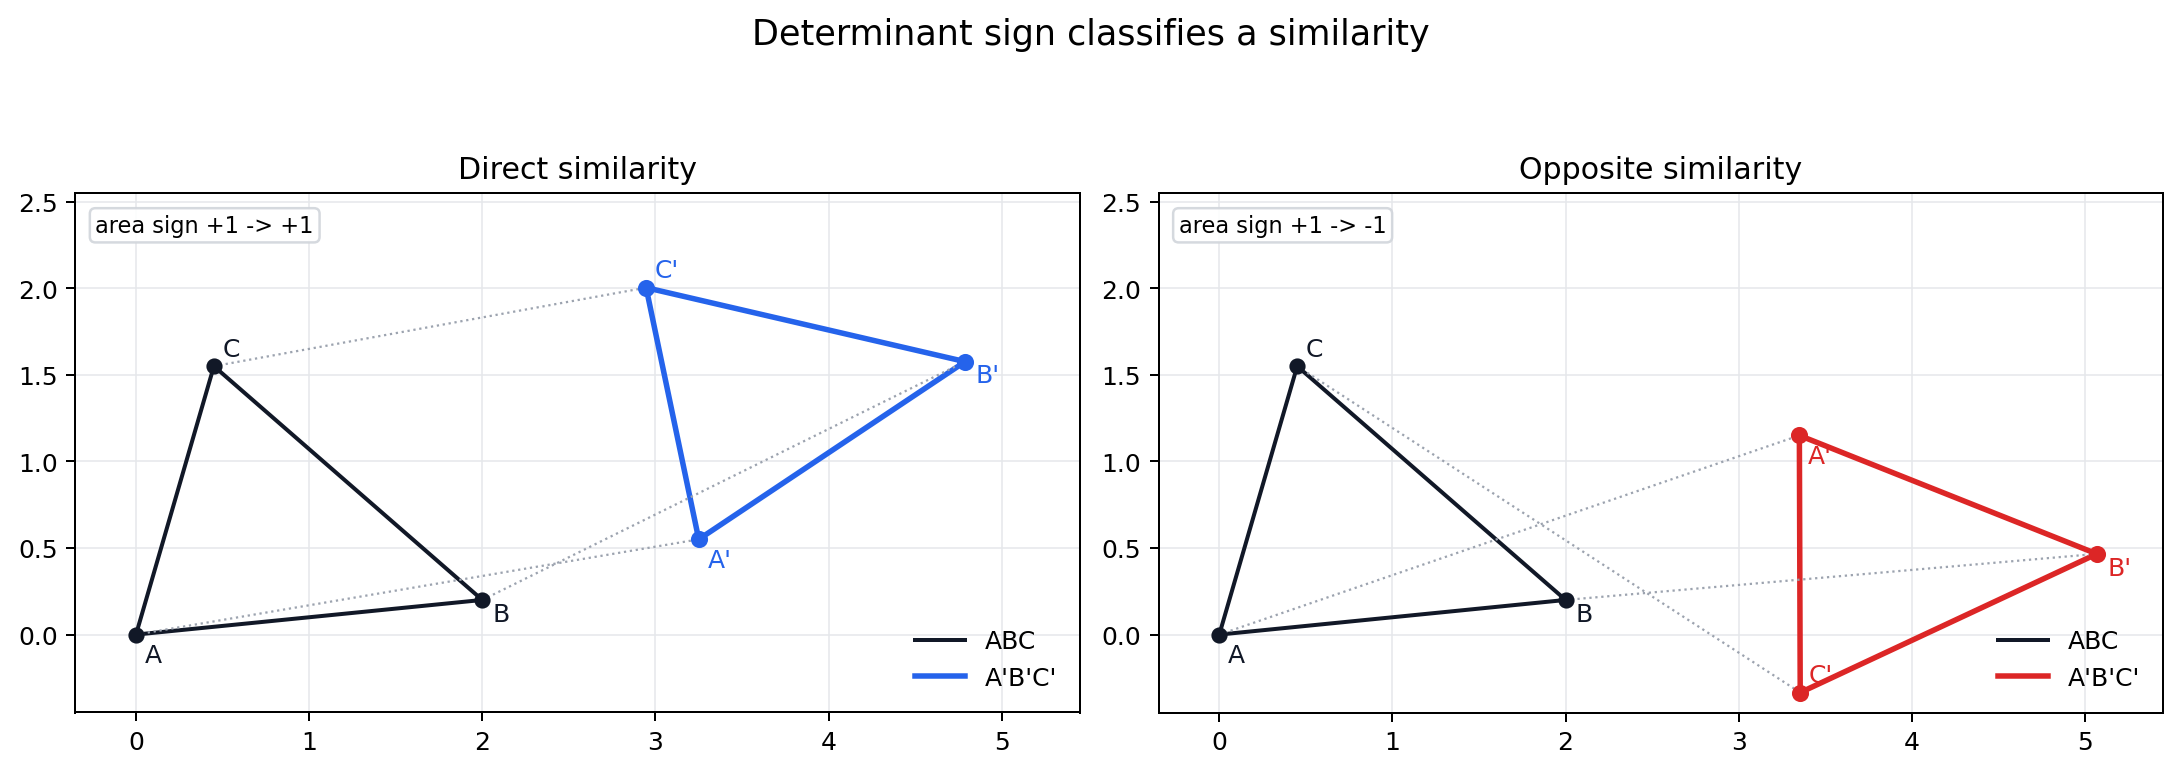

{'base_oriented_area': 1.5050000000000001,
 'direct_oriented_area': 1.2738320000000007,
 'opposite_oriented_area': -1.2738320000000005,
 'direct_length_scale_residual': 3.3306690738754696e-16,
 'opposite_length_scale_residual': 2.220446049250313e-16}

In [6]:
base = np.array([[0.0, 0.0], [2.0, 0.2], [0.45, 1.55]])
base_z = base[:, 0] + 1j * base[:, 1]
a_direct = 0.92 * complex(math.cos(math.radians(28)), math.sin(math.radians(28)))
b_direct = complex(3.25, 0.55)
a_opp = 0.92 * complex(math.cos(math.radians(-16)), math.sin(math.radians(-16)))
b_opp = complex(3.35, 1.15)
direct_z = a_direct * base_z + b_direct
opp_z = a_opp * np.conjugate(base_z) + b_opp
direct = np.column_stack([direct_z.real, direct_z.imag])
opp = np.column_stack([opp_z.real, opp_z.imag])

area0 = oriented_area(base)
area_direct = oriented_area(direct)
area_opp = oriented_area(opp)
side0 = np.linalg.norm(np.roll(base, -1, axis=0) - base, axis=1)
side_direct = np.linalg.norm(np.roll(direct, -1, axis=0) - direct, axis=1)
side_opp = np.linalg.norm(np.roll(opp, -1, axis=0) - opp, axis=1)

fig, axes = plt.subplots(1, 2, figsize=(12.0, 4.4), constrained_layout=True)
label_offsets = {"A": (0.05, -0.16), "B": (0.06, -0.12), "C": (0.05, 0.06), "A'": (0.05, -0.16), "B'": (0.06, -0.12), "C'": (0.05, 0.06)}
for ax, image, title, color, area in [
    (axes[0], direct, "Direct similarity", "#2563eb", area_direct),
    (axes[1], opp, "Opposite similarity", "#dc2626", area_opp),
]:
    ax.plot(np.vstack([base, base[0]])[:, 0], np.vstack([base, base[0]])[:, 1], color="#111827", lw=1.6, label="ABC")
    ax.plot(np.vstack([image, image[0]])[:, 0], np.vstack([image, image[0]])[:, 1], color=color, lw=2.2, label="A'B'C'")
    for label, P in zip(["A", "B", "C"], base):
        ax.scatter(*P, color="#111827", s=30, zorder=4)
        dx, dy = label_offsets[label]
        ax.text(P[0] + dx, P[1] + dy, label, color="#111827")
    for label, P in zip(["A'", "B'", "C'"], image):
        ax.scatter(*P, color=color, s=34, zorder=4)
        dx, dy = label_offsets[label]
        ax.text(P[0] + dx, P[1] + dy, label, color=color)
    for P, Q in zip(base, image):
        ax.plot([P[0], Q[0]], [P[1], Q[1]], color="#9ca3af", lw=0.9, ls=":")
    ax.text(
        0.02,
        0.96,
        f"area sign {np.sign(area0):+.0f} -> {np.sign(area):+.0f}",
        transform=ax.transAxes,
        va="top",
        ha="left",
        fontsize=9,
        bbox=dict(boxstyle="round,pad=0.25", facecolor="white", edgecolor="#d1d5db", alpha=0.9),
    )
    ax.set_title(title, fontsize=12)
    ax.set_aspect("equal")
    ax.set_xlim(-0.35, 5.45)
    ax.set_ylim(-0.45, 2.55)
    ax.grid(True, color="#e5e7eb", lw=0.6)
    ax.legend(frameon=False, loc="lower right")
fig.suptitle("Determinant sign classifies a similarity", y=1.05, fontsize=14)
path = savefig("direct_opposite_similarity_classifier.png", fig)

x, y, ar, ai = sp.symbols("x y ar ai", real=True)
M_direct = sp.Matrix([[ar, -ai], [ai, ar]])
M_opp = sp.Matrix([[ar, ai], [ai, -ar]])
checks["symbolic_invariants"]["direct_linear_determinant"] = str(sp.factor(M_direct.det()))
checks["symbolic_invariants"]["opposite_linear_determinant"] = str(sp.factor(M_opp.det()))
checks["numeric_invariants"]["direct_opposite_classifier"] = {
    "base_oriented_area": float(area0),
    "direct_oriented_area": float(area_direct),
    "opposite_oriented_area": float(area_opp),
    "direct_length_scale_residual": float(np.max(np.abs(side_direct / side0 - abs(a_direct)))),
    "opposite_length_scale_residual": float(np.max(np.abs(side_opp / side0 - abs(a_opp)))),
}
assert sp.factor(M_direct.det()) == ar**2 + ai**2
assert sp.factor(M_opp.det()) == -ar**2 - ai**2
assert area0 * area_direct > 0
assert area0 * area_opp < 0
assert checks["numeric_invariants"]["direct_opposite_classifier"]["direct_length_scale_residual"] < 1e-12
assert checks["numeric_invariants"]["direct_opposite_classifier"]["opposite_length_scale_residual"] < 1e-12

display_artifact(path, width=860)
checks["numeric_invariants"]["direct_opposite_classifier"]


## 6. Applied lab: nested copies of a synthetic map

The source chapter ends with exercises about maps drawn at different scales, including the possibility that one copy has been turned over. The lab below uses a synthetic image, not a scan or textbook figure, so the transformation is fully controlled. We draw a small map-like raster with landmarks, then place direct and opposite similarity copies into one canvas.

The inspection target is practical: the route shape survives both transformations, but the labels and handedness reveal which copy was reflected. This is the same determinant sign test from the previous section, now visible in pixels.


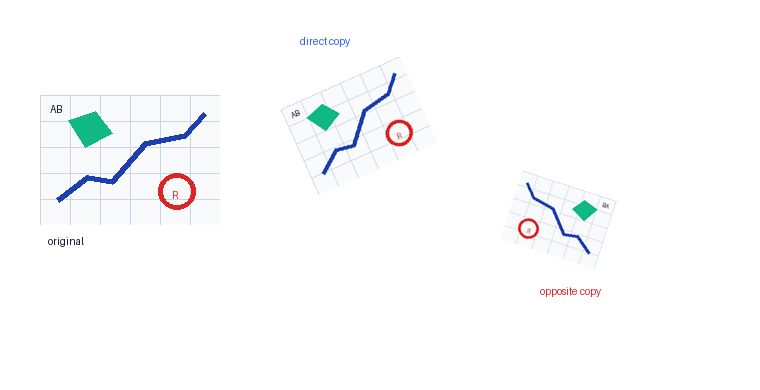

{'base_image_size': [180, 130],
 'direct_copy_size': [158, 140],
 'opposite_copy_size': [117, 100],
 'canvas_pixel_std': 21.686996233856256,
 'base_pixel_std': 51.63568310125316,
 'direct_declared_scale': 0.72,
 'opposite_declared_scale': 0.55}

In [7]:
base_img = PILImage.new("RGBA", (180, 130), (248, 250, 252, 255))
draw = ImageDraw.Draw(base_img)
# Grid and a route give the raster enough geometry to reveal scale, rotation, and reflection.
for x0 in range(0, 181, 30):
    draw.line([(x0, 0), (x0, 130)], fill=(203, 213, 225, 255), width=1)
for y0 in range(0, 131, 26):
    draw.line([(0, y0), (180, y0)], fill=(203, 213, 225, 255), width=1)
route = [(18, 105), (48, 82), (72, 86), (105, 48), (145, 40), (165, 18)]
draw.line(route, fill=(30, 64, 175, 255), width=6, joint="curve")
draw.polygon([(28, 25), (55, 16), (72, 38), (45, 52)], fill=(16, 185, 129, 255))
draw.ellipse((118, 78, 155, 114), outline=(220, 38, 38, 255), width=5)
draw.text((10, 8), "AB", fill=(15, 23, 42, 255))
draw.text((132, 94), "R", fill=(220, 38, 38, 255))
base_path = DATA_DIR / "synthetic_similarity_map.png"
base_img.save(base_path)
artifact_paths[base_path.name] = base_path
checks["artifacts"][base_path.name] = rel(base_path)

canvas = PILImage.new("RGBA", (760, 390), (255, 255, 255, 255))
canvas.alpha_composite(base_img, (40, 95))

def paste_direct(img: PILImage.Image, scale: float, angle: float, offset: tuple[int, int]) -> PILImage.Image:
    resized = img.resize((round(img.width * scale), round(img.height * scale)), PILImage.Resampling.BICUBIC)
    rotated = resized.rotate(angle, expand=True, resample=PILImage.Resampling.BICUBIC)
    canvas.alpha_composite(rotated, offset)
    return rotated

def paste_opposite(img: PILImage.Image, scale: float, angle: float, offset: tuple[int, int]) -> PILImage.Image:
    reflected = img.transpose(PILImage.Transpose.FLIP_LEFT_RIGHT)
    resized = reflected.resize((round(reflected.width * scale), round(reflected.height * scale)), PILImage.Resampling.BICUBIC)
    rotated = resized.rotate(angle, expand=True, resample=PILImage.Resampling.BICUBIC)
    canvas.alpha_composite(rotated, offset)
    return rotated

direct_copy = paste_direct(base_img, 0.72, 24, (280, 56))
opp_copy = paste_opposite(base_img, 0.55, -18, (500, 170))
label_draw = ImageDraw.Draw(canvas)
label_draw.text((48, 235), "original", fill=(15, 23, 42, 255))
label_draw.text((300, 35), "direct copy", fill=(37, 99, 235, 255))
label_draw.text((540, 285), "opposite copy", fill=(220, 38, 38, 255))

lab_path = FIG_DIR / "nested_image_similarity_lab.png"
canvas.convert("RGB").save(lab_path)
artifact_paths[lab_path.name] = lab_path
checks["artifacts"][lab_path.name] = rel(lab_path)

canvas_arr = np.asarray(canvas.convert("RGB"), dtype=float)
base_arr = np.asarray(base_img.convert("RGB"), dtype=float)
checks["numeric_invariants"]["nested_image_lab"] = {
    "base_image_size": list(base_img.size),
    "direct_copy_size": list(direct_copy.size),
    "opposite_copy_size": list(opp_copy.size),
    "canvas_pixel_std": float(canvas_arr.std()),
    "base_pixel_std": float(base_arr.std()),
    "direct_declared_scale": 0.72,
    "opposite_declared_scale": 0.55,
}
assert canvas_arr.std() > 10
assert base_arr.std() > 10
assert direct_copy.size[0] > 0 and opp_copy.size[0] > 0

display_artifact(lab_path, width=860)
checks["numeric_invariants"]["nested_image_lab"]


## Final sanity checks

The final cell is intentionally redundant: it checks files, sizes, exact symbolic identities, numeric geometry residuals, and a small manifest table. This makes the notebook auditable as a standalone chapter artifact rather than a sequence of decorative images.


In [8]:
# First verify the visual/data artifacts made by the concept cells.
initial_paths = list(dict.fromkeys(artifact_paths.values()))
assert_artifacts(initial_paths, min_bytes=100)

# Coarse visual nonblank checks for raster artifacts.
raster_stats = {}
for path in initial_paths:
    if path.suffix.lower() in {".png", ".jpg", ".jpeg"}:
        arr = np.asarray(PILImage.open(path).convert("RGB"), dtype=float)
        raster_stats[rel(path)] = {"std": float(arr.std()), "shape": list(arr.shape)}
        assert arr.std() > 1.0, f"Raster artifact appears blank: {path}"
checks["raster_stats"] = raster_stats

# Save a compact numeric table for external audit and human inspection.
invariant_rows = []
for group, payload in checks["numeric_invariants"].items():
    for key, value in payload.items():
        if isinstance(value, (int, float, np.floating)):
            invariant_rows.append({"group": group, "quantity": key, "value": float(value)})
invariant_table_path = TABLE_DIR / "numeric_invariants.csv"
write_csv(invariant_table_path, invariant_rows)
artifact_paths[invariant_table_path.name] = invariant_table_path
checks["artifacts"][invariant_table_path.name] = rel(invariant_table_path)

summary_path = CHECK_DIR / "similarity_invariants_summary.json"
visual_summary_path = CHECK_DIR / "visual_summary.json"
artifact_paths[summary_path.name] = summary_path
artifact_paths[visual_summary_path.name] = visual_summary_path
checks["artifacts"][summary_path.name] = rel(summary_path)
checks["artifacts"][visual_summary_path.name] = rel(visual_summary_path)

manifest_path = TABLE_DIR / "artifact_manifest.csv"
artifact_paths[manifest_path.name] = manifest_path
checks["artifacts"][manifest_path.name] = rel(manifest_path)

# Include generated check/table artifacts in sizes and manifests.
final_paths = list(dict.fromkeys(artifact_paths.values()))
checks["artifact_sizes"] = {rel(path): path.stat().st_size for path in final_paths if path.exists()}
write_json(summary_path, checks)
write_json(visual_summary_path, checks)

manifest_rows = []
for name, path in sorted(artifact_paths.items()):
    manifest_rows.append({
        "artifact": name,
        "kind": path.parent.name,
        "book_relative_path": rel(path),
        "bytes": path.stat().st_size,
    })
write_csv(manifest_path, manifest_rows)

# Update summaries once table/check file sizes have settled.
checks["artifact_sizes"] = {rel(path): path.stat().st_size for path in final_paths}
write_json(summary_path, checks)
write_json(visual_summary_path, checks)

assert_artifacts(final_paths, min_bytes=100)
assert checks["symbolic_invariants"]["direct_similarity_fixed_point_residual"] == "0"
assert checks["symbolic_invariants"]["direct_linear_determinant"] == "ai**2 + ar**2"
assert checks["symbolic_invariants"]["opposite_linear_determinant"] == "-ai**2 - ar**2"
assert checks["numeric_invariants"]["dilation"]["max_parallel_cross_residual"] < 1e-12
assert checks["numeric_invariants"]["nine_point_center"]["max_nine_point_radius_residual"] < 1e-10
assert checks["numeric_invariants"]["spiral_similarity"]["max_orbit_scale_residual"] < 1e-12
assert checks["numeric_invariants"]["direct_opposite_classifier"]["direct_length_scale_residual"] < 1e-12

display(Markdown("### Artifact manifest"))
display(pd.DataFrame(manifest_rows).sort_values(["kind", "artifact"]).reset_index(drop=True))

display(Markdown("### Numeric invariant checks"))
display(pd.DataFrame(invariant_rows).sort_values(["group", "quantity"]).reset_index(drop=True))

{
    "artifact_count": len(final_paths),
    "summary_json": rel(summary_path),
    "manifest_csv": rel(manifest_path),
    "max_raster_std_checked": max(item["std"] for item in raster_stats.values()),
}


### Artifact manifest

,artifact,kind,book_relative_path,bytes
0,similarity_invariants_summary.json,checks,artifacts/chapter-05/checks/similarity_invaria...,5388
1,visual_summary.json,checks,artifacts/chapter-05/checks/visual_summary.json,5388
2,synthetic_similarity_map.png,data,artifacts/chapter-05/data/synthetic_similarity...,1887
3,dilation_parallel_lines.png,figures,artifacts/chapter-05/figures/dilation_parallel...,85861
4,direct_opposite_similarity_classifier.png,figures,artifacts/chapter-05/figures/direct_opposite_s...,123364
5,homothety_centers_two_circles.png,figures,artifacts/chapter-05/figures/homothety_centers...,102243
6,nested_image_similarity_lab.png,figures,artifacts/chapter-05/figures/nested_image_simi...,33861
7,nine_point_center_under_scaling.png,figures,artifacts/chapter-05/figures/nine_point_center...,119461
8,spiral_similarity_fixed_point.html,html,artifacts/chapter-05/html/spiral_similarity_fi...,4877036
9,artifact_manifest.csv,tables,artifacts/chapter-05/tables/artifact_manifest.csv,1176


### Numeric invariant checks

,group,quantity,value
0,centers_of_similitude,external_scale,1.947368e+00
1,centers_of_similitude,internal_scale,-1.947368e+00
2,centers_of_similitude,max_external_collinearity_residual,1.776357e-15
3,centers_of_similitude,max_internal_collinearity_residual,4.440892e-16
4,dilation,max_length_scale_residual,4.440892e-16
5,dilation,max_parallel_cross_residual,8.881784e-16
6,direct_opposite_classifier,base_oriented_area,1.505000e+00
7,direct_opposite_classifier,direct_length_scale_residual,3.330669e-16
8,direct_opposite_classifier,direct_oriented_area,1.273832e+00
9,direct_opposite_classifier,opposite_length_scale_residual,2.220446e-16


{'artifact_count': 11,
 'summary_json': 'artifacts/chapter-05/checks/similarity_invariants_summary.json',
 'manifest_csv': 'artifacts/chapter-05/tables/artifact_manifest.csv',
 'max_raster_std_checked': 51.63568310125316}

## Takeaways

A Euclidean similarity is rigid about shape but flexible about size. Dilations reveal why a non-translation homothety has a center and why unequal circles have two centers of similitude. The nine-point center is not a mysterious extra triangle center in this view: it is the midpoint of `OH` because two half-scale maps land on the same circle. General similarities add rotation or reflection to dilation. The determinant sign of the linear part tells whether the map is direct or opposite, and the fixed-point equation tells where the whole transformation is anchored unless the map is an isometric edge case such as a translation.
